# K-Nearest Neighbors (KNN) Classifier

K-Nearest Neighbors (KNN) is a simple, easy-to-understand, and versatile supervised machine learning algorithm used for both classification and regression. It is a **non-parametric** and **instance-based** algorithm, meaning it does not make assumptions about the underlying data distribution and does not learn a model. Instead, it memorizes the training dataset and performs predictions based on historical similarity.

## How KNN Works
1. **Choose K**: Select the number of nearest neighbors, $K$ (e.g., $K=5$).
2. **Calculate Distance**: Measure the distance (usually Euclidean distance) between the query point and all training data points.
3. **Identify Neighbors**: Select the $K$ training instances closest to the query point.
4. **Vote/Average**:
   - **For Classification**: Assign the class label that is most common among the $K$ neighbors (majority vote).
   - **For Regression**: Assign the average value of the $K$ neighbors.

## 1. Import Libraries

Let's import the necessary Python packages for loading the dataset, preprocessing features, training the KNN model, evaluating, and visualizing decision boundaries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## 2. Load and Prepare the Dataset

We will use the famous **Iris Flower Dataset** for our demonstration. To visualize the decision boundaries in 2D, we will only use the first two features (Sepal Length and Sepal Width).

In [2]:
# Load Iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Sepal Length, Sepal Width
y = iris.target

# Split dataset into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 120
Testing samples: 30


### Feature Scaling

Since KNN depends on distance calculations, features on larger scales can dominate the distance metric. Therefore, it is highly recommended to standardize features to have a mean of 0 and variance of 1.

In [3]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Train the KNN Model

We initialize the KNN classifier with $K = 5$ neighbors and fit it on the scaled training data.

In [4]:
# Initialize classifier with K=5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# Fit model
knn.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = knn.predict(X_test_scaled)

## 4. Evaluate Performance

We evaluate how well our model performs using metrics like **accuracy**, a **confusion matrix**, and a **classification report**.

KNN (K=5) Test Accuracy: 63.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.47      0.70      0.56        10
   virginica       0.40      0.20      0.27        10

    accuracy                           0.63        30
   macro avg       0.62      0.63      0.61        30
weighted avg       0.62      0.63      0.61        30



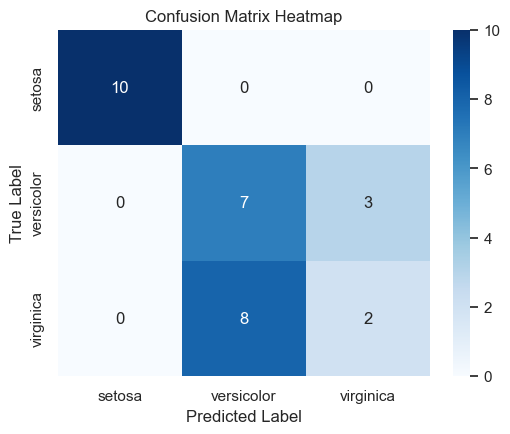

In [5]:
# Print overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN (K=5) Test Accuracy: {accuracy * 100:.2f}%\n")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## 5. Visualize Decision Boundary

By plotting the decision boundary, we can visually inspect how KNN divides the 2D space for the three different flower classes.

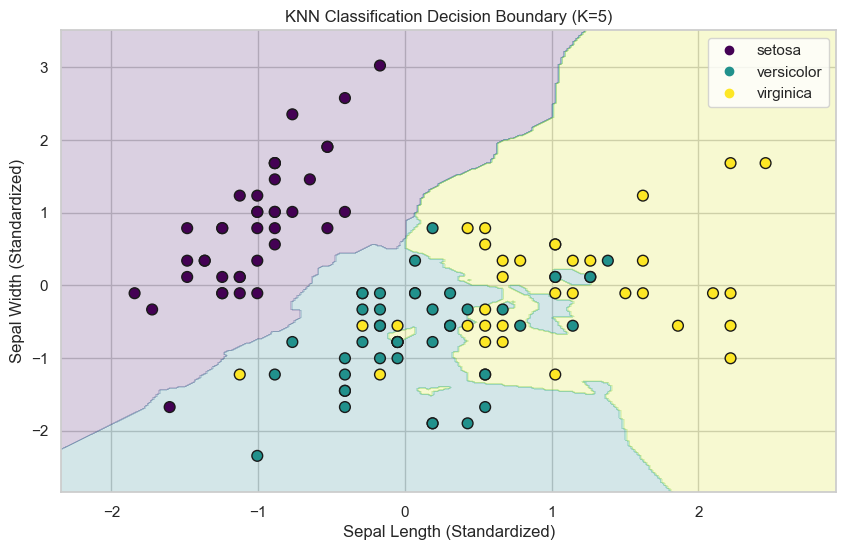

In [6]:
# Create mesh grid
x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict for all points in mesh grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot contour background
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.2, cmap="viridis")

# Scatter plot for training points
scatter = plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, 
                      cmap="viridis", edgecolor="k", s=60)
plt.xlabel("Sepal Length (Standardized)")
plt.ylabel("Sepal Width (Standardized)")
plt.title("KNN Classification Decision Boundary (K=5)")
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names))
plt.show()

## 6. Tuning Hyperparameter $K$

Choosing the right value of $K$ is essential to balance bias and variance:
- A **small K** (e.g., $K=1$) makes the model highly sensitive to noise/outliers (overfitting).
- A **large K** (e.g., $K=50$) smooths the boundaries too much and ignores local structures (underfitting).

Let's test various values of $K$ and see how it affects testing accuracy.

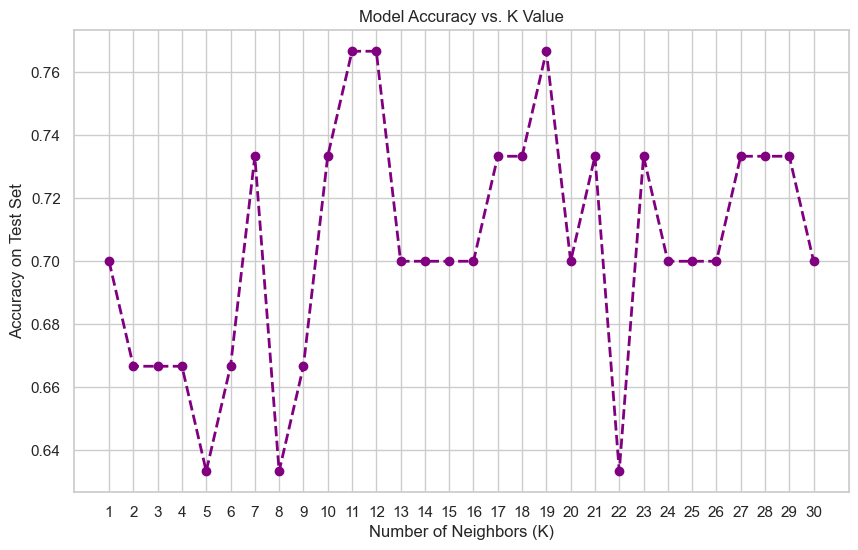

In [7]:
k_range = range(1, 31)
scores = []

for k in k_range:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_scaled, y_train)
    pred = clf.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, pred))

# Plot the accuracy vs K
plt.figure(figsize=(10, 6))
plt.plot(k_range, scores, marker='o', color='purple', linestyle='--', linewidth=2)
plt.title("Model Accuracy vs. K Value")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy on Test Set")
plt.xticks(k_range)
plt.show()

**We note that its best to keep K about 11 or 12 which achieves far greater results than the current 63pc we got with n=5**

### we can condlude that the KNN algo is kind of a lazy learner as it skips the training phase entirely and just places the new points in the same cluster as its N nearest neighbours....thats it! ####